In [1]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')
%load_ext autoreload
%autoreload 2

In [10]:
import pandas as pd
import numpy as np
import globals
from pathlib import Path
import matplotlib.pyplot as plt

In [6]:
filepath = Path("/Users/benny/Documents/swc/trait_analyses/trait_dataframes/df1.csv")
trait_df = pd.read_csv(filepath, index_col=0)

## Pie chart for adaptation categories

In [90]:
from pypalettes import load_cmap
from pypalettes import load_palette
cmap = load_cmap("excel_Slipstream")
colors = load_palette("excel_Slipstream")
label_colors = colors

([<matplotlib.patches.Wedge at 0x124de3750>,
 [Text(0.48819049467746223, 1.008002996476982, 'NO ADAPT'),
  Text(-1.1198645479025562, -0.017418218938906615, 'SUSTAINED'),
  Text(-0.2078135028601254, -1.1005514745022174, 'ADAPT & REVERSE'),
  Text(0.5499132269732316, -0.9757025380718691, 'CONT SHFIT'),
  Text(1.029675383170745, -0.4406456686411201, 'SHIFT POST SOCIAL')],
 [Text(0.3051190591734138, 0.6300018727981138, '35.6%'),
  Text(-0.6999153424390975, -0.010886386836816633, '29.2%'),
  Text(-0.12988343928757837, -0.6878446715638857, '14.4%'),
  Text(0.3436957668582697, -0.6098140862949182, '7.9%'),
  Text(0.6435471144817155, -0.2754035429007, '12.9%')])

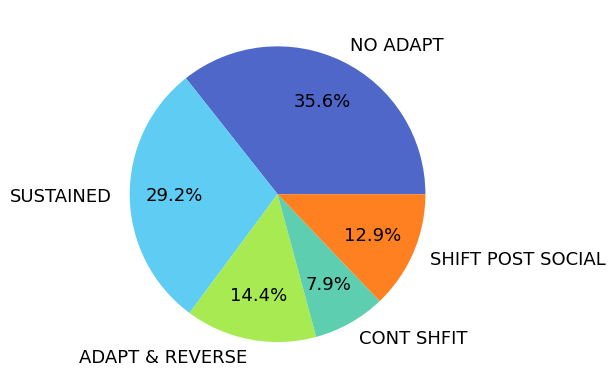

In [96]:
# fractions of different adaptation categories
shift_class = trait_df['shift_class'].tolist()

from collections import Counter
items = list(Counter(shift_class).keys())
counts = list(Counter(shift_class).values())

df = pd.DataFrame(
    {"counts": [72, 59, 29, 16, 26]},
    index=["NO ADAPT", "SUSTAINED", "ADAPT & REVERSE", "CONT SHFIT", "SHIFT POST SOCIAL"],
)

fig, ax = plt.subplots()
ax.pie(counts, labels=items,
                textprops={'fontsize':13},
                autopct='%1.1f%%',
                pctdistance=0.7, labeldistance=1.12,
                colors=colors)

#plot = df.plot.pie(y="counts", figsize=(4,5))

## Confusion matrix for dyads

In [ ]:
opponents = list(trait_df['opponent'])

In [105]:
shift_class_player = shift_class

In [194]:
shift_class_opponent = []
for i, opponent in enumerate(opponents):
    shift_class = trait_df['shift_class'][opponent]
    shift_class_opponent.append(shift_class)

trait_df['shift_class_opponent'] = shift_class_opponent

In [126]:
# Importing LabelEncoder from Sklearn 
# library from preprocessing Module.
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()

# Using .fit_transform function to fit label
# encoder and return encoded label
player_labels = le.fit_transform(shift_class_player)
opponent_labels = le.fit_transform(shift_class_opponent)

In [147]:
# confusion matrices

# 1. likelihood of pairings

In [174]:
# create list of player-opponent pairs
#dyads = list(zip(player_labels, opponent_labels))
dyads = list(zip(shift_class_player, shift_class_opponent))

count = Counter(dyads) # this creates a dict with items being the possible dyads and values being the frequency of appearance

sorted_counts = sorted(count.items(), key=lambda tup: (tup[0][1], tup[0][0]))

types_of_dyads = [dyad for dyad, freq in sorted_counts]
frequency_of_dyads = [freq for dyad, freq in sorted_counts]

In [151]:
import seaborn as sns

In [172]:
cmap = load_cmap("Mint")

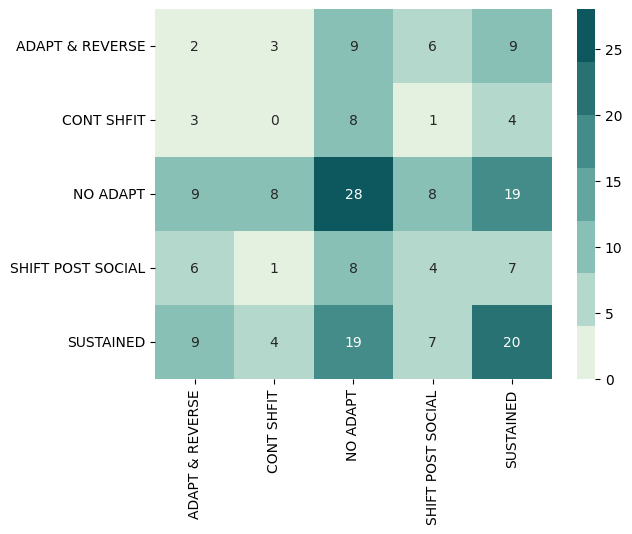

In [176]:
cm = pd.DataFrame(
    0,
    index=sorted(set(shift_class_player)),
    columns=sorted(set(shift_class_opponent))
)

for (player,opponent), freq in count.items():
    cm.loc[player, opponent] = freq

sns.heatmap(cm, annot=True, cmap=cmap)
plt.show()

In [ ]:
# confusion matrices

# 2. proportion scores

In [ ]:
proportion_scores = list(trait_df['proportion_score'])

In [195]:
heatmap_data = pd.pivot_table(
    trait_df,
    values='proportion_score',
    index='shift_class',
    columns='shift_class_opponent',
    aggfunc='mean'
)

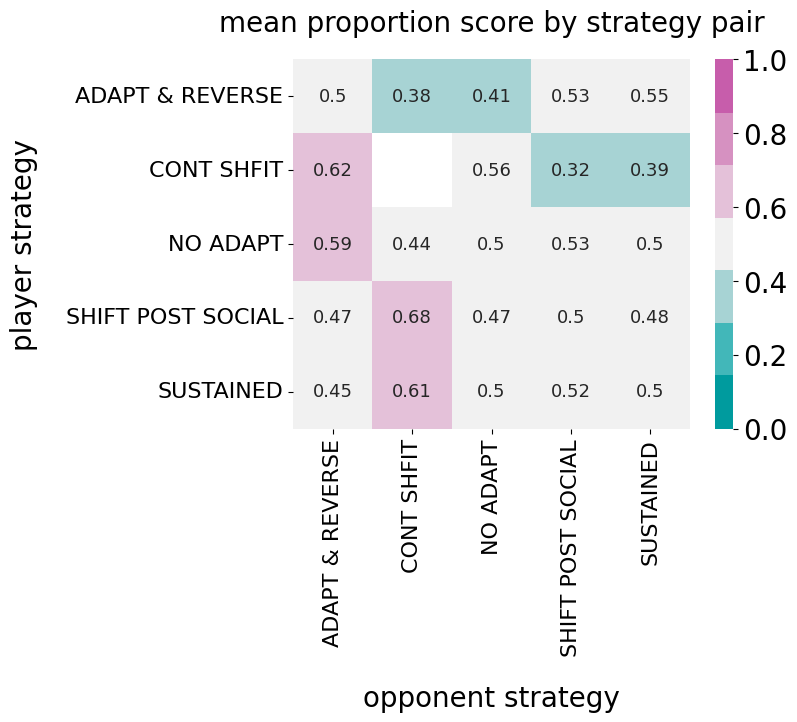

In [226]:
cmap = load_cmap("Tropic")

# cell values
# 0.5: equal performance
# 0.6 and above: row strategy typically gets 60+% of points against column strategy
# 0.4 and below: column strategy typically gets 60+% of points against column strategy

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1, 
    annot_kws={"size":13}
)

ax = plt.gca()
ax.tick_params(axis='both',labelsize=16)

ax.set_title("mean proportion score by strategy pair", fontsize=20, pad=20)
plt.xlabel('opponent strategy', fontsize=20, labelpad=20)
plt.ylabel('player strategy',  fontsize=20, labelpad=20)


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.show()